# IMDb Sentiment Analysis with Transformers

This notebook uses a pretrained Transformer model for sentiment analysis on real IMDb reviews pulled from Hugging Face Datasets.

In [27]:
%pip install -q datasets pandas scikit-learn matplotlib seaborn torch tqdm
%pip install -q -t ./.pydeps_transformers "transformers==4.41.2"

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.3.0 requires fsspec[http]<=2025.9.0,>=2023.1.0, but you have fsspec 2026.3.0 which is incompatible.
fastf1 3.4.0 requires pandas<3.0.0,>=1.4.1, but you have pandas 3.0.2 which is incompatible.
kubernetes 34.1.0 requires urllib3<2.4.0,>=1.24.2, but you have urllib3 2.6.3 which is incompatible.
langchain-core 0.3.79 requires packaging<26.0.0,>=23.2.0, but you have packaging 26.0 which is incompatible.
outlines 0.0.46 requires numpy<2.0.0, but you have numpy 2.4.4 which is incompatible.
streamlit 1.44.1 requires packaging<25,>=20, but you have packaging 26.0 which is incompatible.
streamlit 1.44.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.2 which is incompatible.
streamlit 1.44.1 requires pillow<12,>=7.1.0, but you have pillow 12.1.1 which is incompatible.
torchaudio 2.2.0+cu118 requires torch==2.

In [28]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datasets import load_dataset

candidate_paths = [
    os.path.abspath("./.pydeps_transformers"),
    os.path.abspath("./notebooks/.pydeps_transformers")
]
local_tf_path = next((p for p in candidate_paths if os.path.isdir(p)), candidate_paths[0])
if local_tf_path not in sys.path:
    sys.path.insert(0, local_tf_path)

for module_name in list(sys.modules):
    if module_name == "transformers" or module_name.startswith("transformers."):
        del sys.modules[module_name]

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [29]:
# Pull real IMDb reviews from Hugging Face Datasets
imdb = load_dataset("imdb")
df = pd.DataFrame(imdb["test"])
df = df.sample(2000, random_state=RANDOM_STATE).reset_index(drop=True)
df = df.rename(columns={"text": "review"})
df["sentiment"] = df["label"].map({1: "positive", 0: "negative"})

print(f"Loaded {len(df)} real held-out IMDb reviews from test split.")
df.head()

Loaded 2000 real held-out IMDb reviews from test split.


,review,label,sentiment
0,I could not believe how terrible and boring th...,0,negative
1,I rented Boogie Nights last week and I could t...,1,positive
2,"First off, this movie is not near complete, my...",0,negative
3,I watched this mini in the early eighties. Sam...,1,positive
4,This movie was never intended as a big-budget ...,1,positive


In [30]:
# Load a pretrained sentiment model and tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, use_safetensors=True)
model.to(device)
model.eval()

print(f"Using device: {device}")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Using device: cpu


In [31]:
# Run batched inference for speed and stability
def predict_batch(batch_texts):
    enc = tokenizer(
        batch_texts,
        truncation=True,
        max_length=512,
        padding=True,
        return_tensors="pt"
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)
        scores, labels = torch.max(probs, dim=-1)
    return labels.cpu().numpy().tolist(), scores.cpu().numpy().tolist()

texts = df["review"].tolist()
predicted_labels = []
predicted_scores = []

for i in tqdm(range(0, len(texts), 32), desc="Inferring"):
    batch = texts[i:i+32]
    labels, scores = predict_batch(batch)
    predicted_labels.extend(labels)
    predicted_scores.extend(scores)

df["pred_label"] = predicted_labels
df["pred_score"] = predicted_scores

df[["review", "sentiment", "label", "pred_label", "pred_score"]].head()

Inferring:   0%|          | 0/63 [00:00<?, ?it/s]

,review,sentiment,label,pred_label,pred_score
0,I could not believe how terrible and boring th...,negative,0,0,0.999771
1,I rented Boogie Nights last week and I could t...,positive,1,1,0.995150
2,"First off, this movie is not near complete, my...",negative,0,0,0.999400
3,I watched this mini in the early eighties. Sam...,positive,1,1,0.993925
4,This movie was never intended as a big-budget ...,positive,1,1,0.988935


In [32]:
# Evaluate performance
y_true = df["label"]
y_pred = df["pred_label"]

acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

Accuracy: 0.8910

              precision    recall  f1-score   support

    negative       0.88      0.91      0.90      1040
    positive       0.90      0.87      0.88       960

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



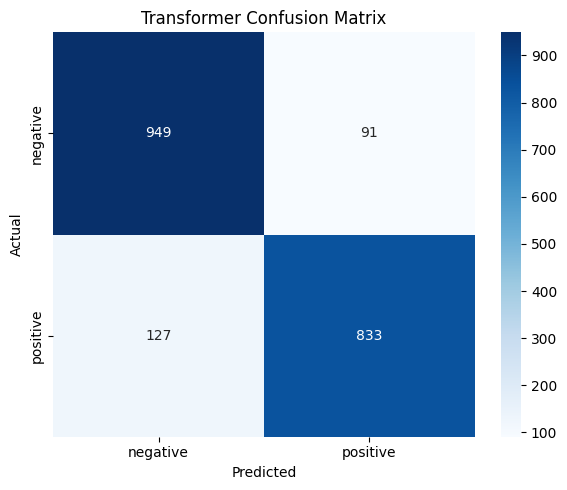

In [33]:
# Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.title("Transformer Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [34]:
# Inspect predictions on real unseen reviews
sample_real = df.sample(5, random_state=RANDOM_STATE).copy()

for _, row in sample_real.iterrows():
    labels, scores = predict_batch([row["review"]])
    pred = "positive" if labels[0] == 1 else "negative"
    print(f"True: {row['sentiment']} | Pred: {pred} | Score: {scores[0]:.4f}")
    print(row["review"][:300].replace("\n", " ") + "...")
    print("-" * 100)

True: positive | Pred: positive | Score: 0.9794
The Elegant Universe brings to light many ideas of the universe and existence. After watching this documentary, one can't help but take a step back and rethink their view on the existence of everything. There is a large cast of scientists, mathematicians and others on both sides of String Theory. It...
----------------------------------------------------------------------------------------------------
True: negative | Pred: positive | Score: 0.9648
The recent release of "Mad Dog Morgan" on Troma DVD is disappointing.This appears to be a censored print for television viewing. Some of the more violent scenes have been edited and portions of the colorful language have been removed. Anyone who viewed the film uncut will be mad as hell at this toxi...
----------------------------------------------------------------------------------------------------
True: positive | Pred: negative | Score: 0.9676
After seeing the trailer it was an easy decisi